In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

In [2]:
# drifters traj

from cstes import drifters_dir
dst = xr.open_dataset(os.path.join(drifters_dir,'L2', 'all_med_variational_10min_v0.nc'))
dst =dst.where(dst.gap_mask==1).where(dst.datetime<pd.to_datetime('2023-07-15T00:00:00.000000000'), drop=True)

#swot
from swot import browse_swot_2km
dfs = browse_swot_2km().reset_index()

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [3]:
# Coloc

dt=12
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [base_dic]

ds = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True).isel(id_comb=0)


307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed


In [23]:
from swot import browse_swot_2km
dfs = browse_swot_2km().reset_index()
files_c = dfs[dfs.cycle_number == 500].file
dss3 = xr.open_dataset(files_c.iloc[0])
dss16 = xr.open_dataset(files_c.iloc[1])
dss3["adt"] = (dss3.duacs_ssha_karin_2_filtered +  dss3.cvl_mean_dynamic_topography_cnes_cls_22).assign_attrs({'long_name' : 'ADT from L3-SWOT-2km', 'units':'m'})
dss16["adt"] = (dss16.duacs_ssha_karin_2_filtered +  dss16.cvl_mean_dynamic_topography_cnes_cls_22).assign_attrs({'long_name' : 'ADT from L3-SWOT-2km', 'units':'m'})

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


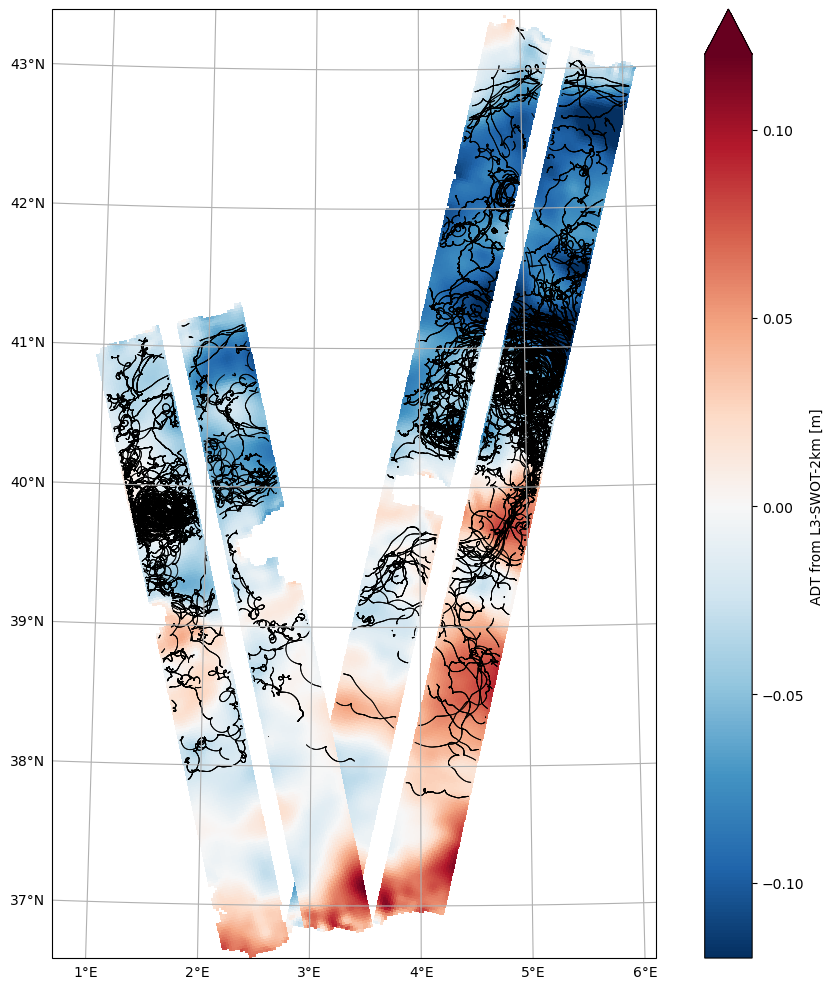

In [24]:
bbox = [0.7, 6.1, 36.6, 43.4]

fig = plt.figure(figsize=(10,10))
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(111, projection=ccrs.Orthographic(ds.longitude.mean().values, ds.latitude.mean().values))

dss3.adt.plot(ax=ax, transform=crs, x='longitude', y='latitude',vmin = -0.12, vmax=0.12, add_colorbar=False, cmap ='RdBu_r')
dss16.adt.plot(ax=ax, transform=crs, x='longitude', y='latitude', vmin = -0.12, vmax=0.12, cmap ='RdBu_r')
ax.scatter(ds.longitude, ds.latitude, transform =crs, color='k', edgecolors='none', s=0.5)

ax.set_extent(bbox)
gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False


#ax.set_title(f'SWOT-2km {pd.to_datetime(dss3.time.mean().values).strftime("%m-%d-%Y")}\n Drifters from {dtmin} to {dtmax}')
fig.tight_layout()

In [ ]:
dfs

In [21]:
rn = 3000
def plot_one_coloc(rn):
    
    ds_ = ds.sel(row_number = rn)
    
    #fig
    fig = plt.figure(figsize=(10,10))
    fig.patch.set_facecolor('white')#no transparancy in png
    dl = 0.1
    bbox = [ds_.longitude.values-dl, ds_.longitude.values+dl, ds_.latitude.values-dl, ds_.latitude.values+dl]
    ax = fig.add_subplot(111, projection=ccrs.Orthographic(ds_.longitude.mean().values, ds_.latitude.mean().values))

    #SWOT
    pass_ = int(ds_.pass_number.values)
    cycle = ds_.cycle_number.values
    file = dfs[(dfs.cycle_number == cycle)&(dfs.pass_number == pass_)].file
    dss = xr.open_dataset(file.iloc[0])
    dss["adt"] = (dss.duacs_ssha_karin_2_filtered +  dss.cvl_mean_dynamic_topography_cnes_cls_22).assign_attrs({'long_name' : 'ADT from SWOT', 'units':'m'})
    dss.where((dss.longitude>bbox[0]-dl)&(dss.longitude<bbox[1]+dl)&(dss.latitude>bbox[2]-dl)&(dss.latitude<bbox[3]+dl)).adt.plot(ax=ax, transform=crs, x='longitude', y='latitude', cmap ='RdBu_r')
    
    #Drifter traj   
    id_ = ds_.drifter_id.values
    dst_ = dst.sel(drifter_id = id_).dropna('datetime')
    dst_.plot.scatter(x='longitude', y='latitude', transform = crs, c='k', edgecolors='none')

    # coloc
    scale=1e-4
    for v in ['acc', 'cor', 'ggd', 'wd'] :
        c = ds_.plot.quiver(x='longitude', y='latitude', u=v+'e', v=v+'n', color=c0[v], pivot='tail', scale=scale, zorder=10, add_guide = False,)
    ax.set_extent(bbox)
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False

    ax.set_title(rn.values)

    return fig

/dev/shm/pbs.2794471.datarmor0/ipykernel_30705/10030767.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for rn in np.random.randint(0, ds.dims['row_number'], 15):
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to 

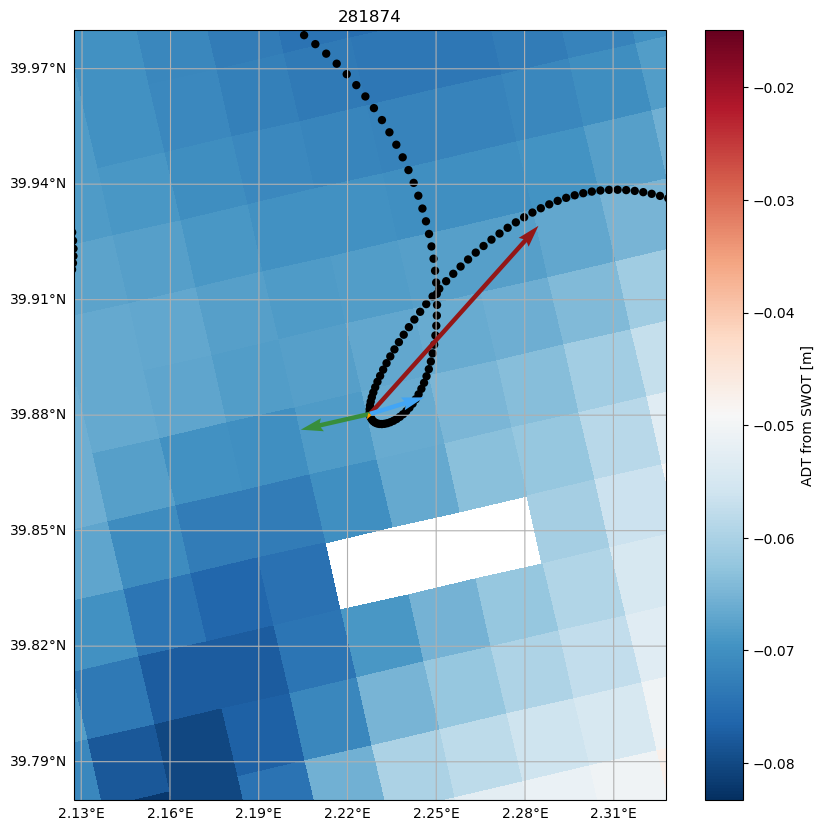

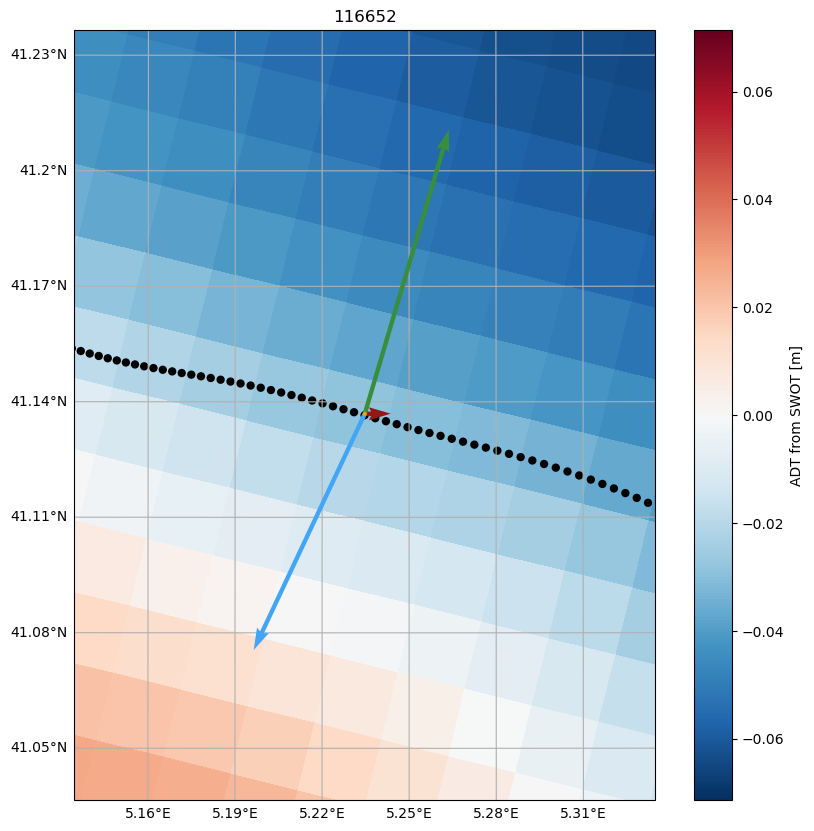

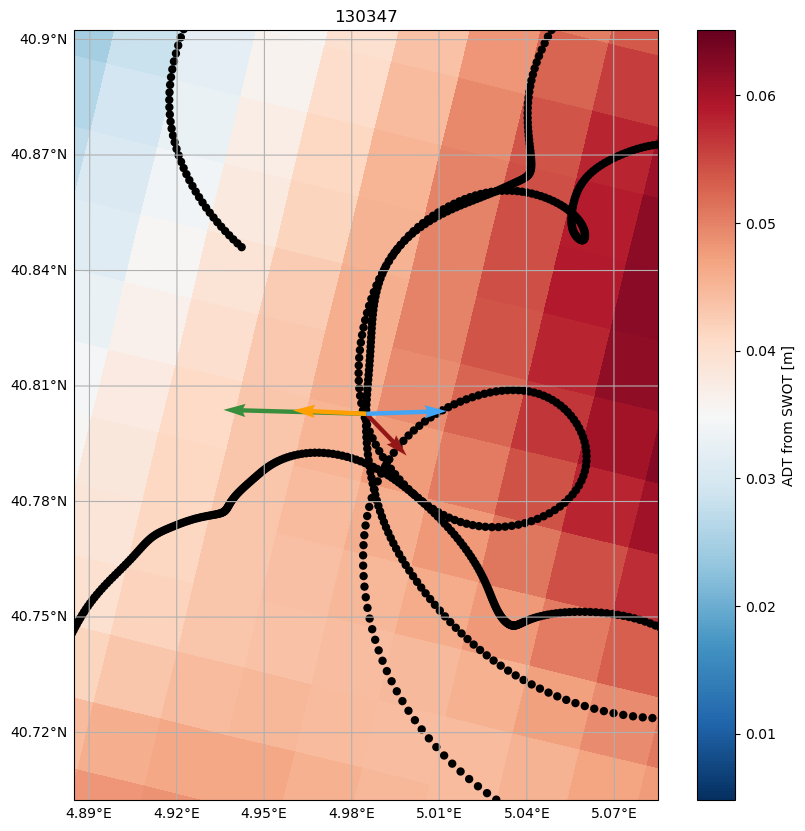

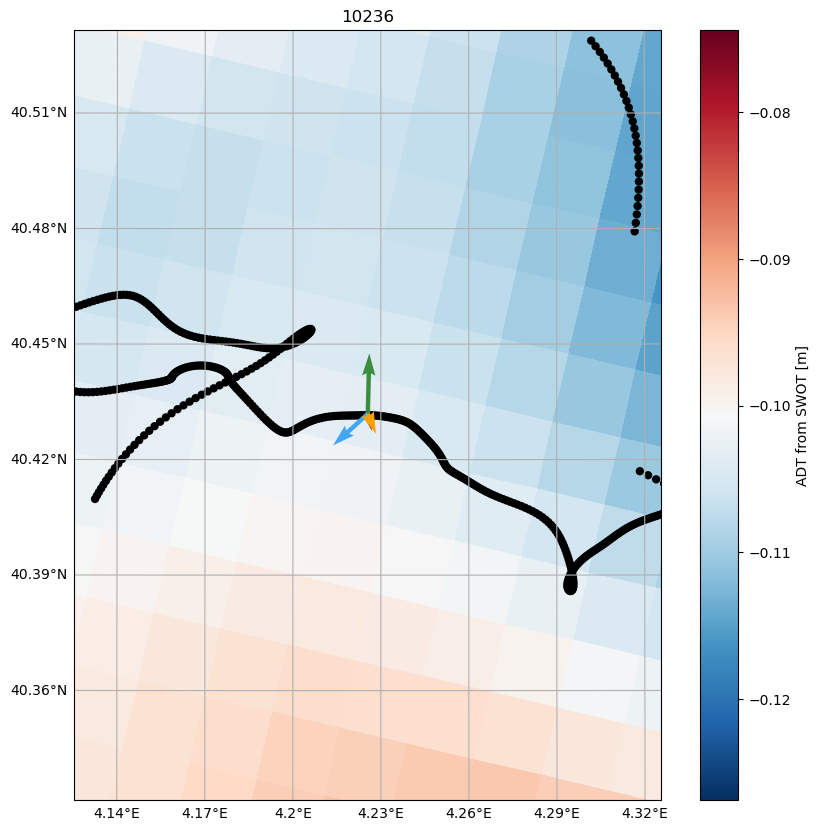

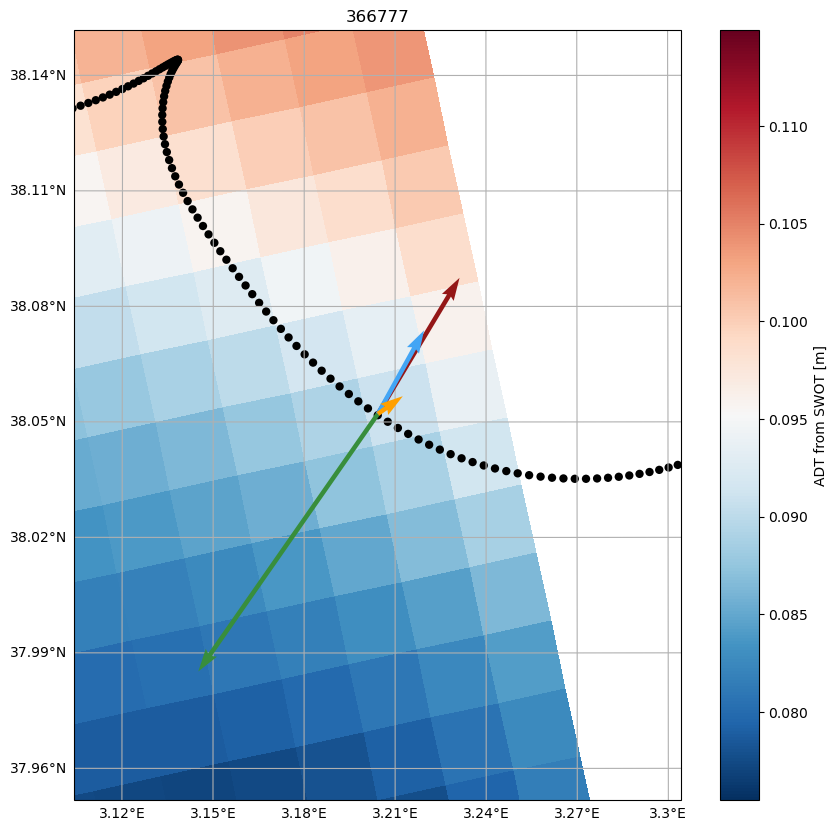

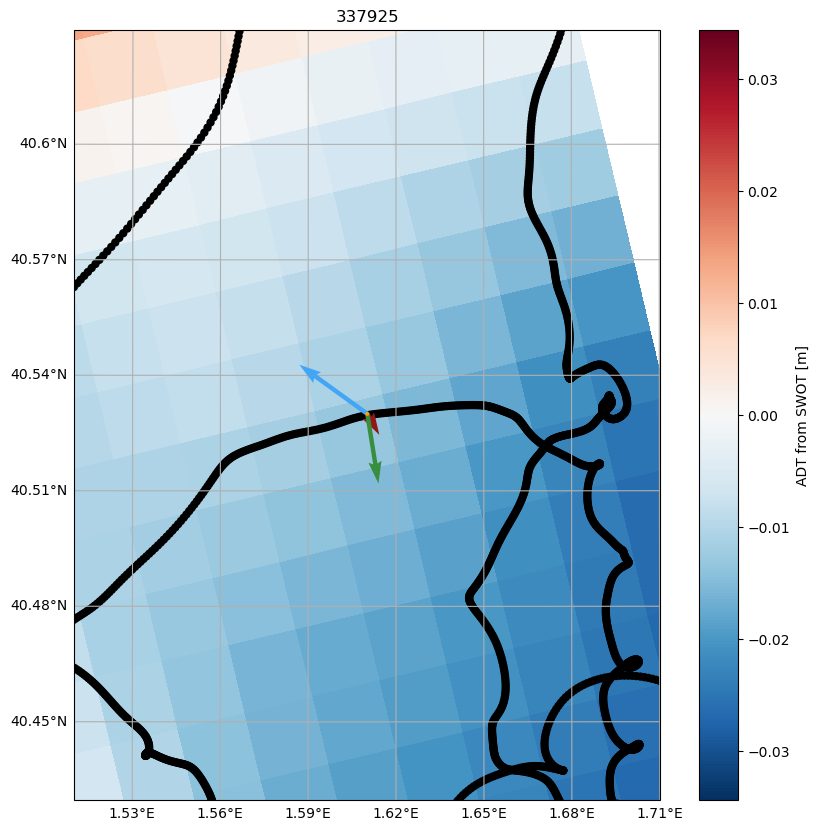

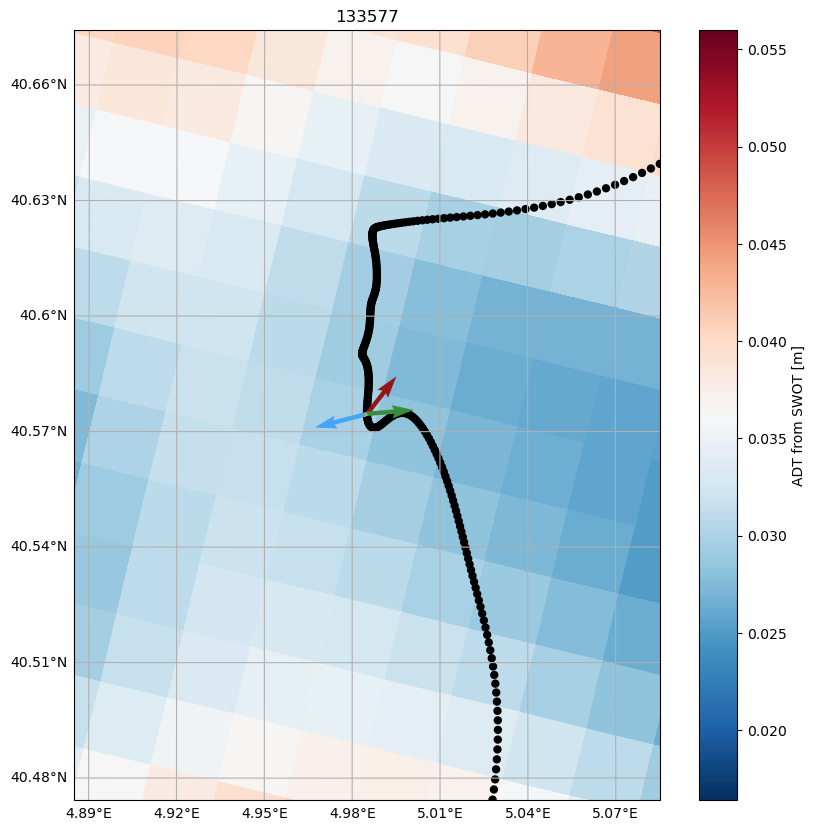

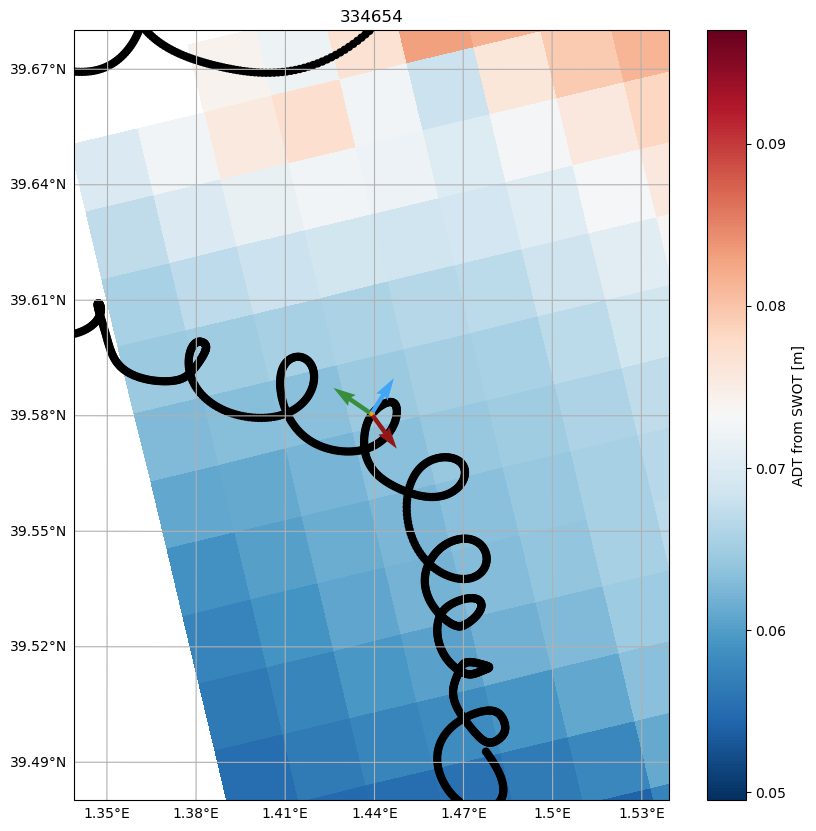

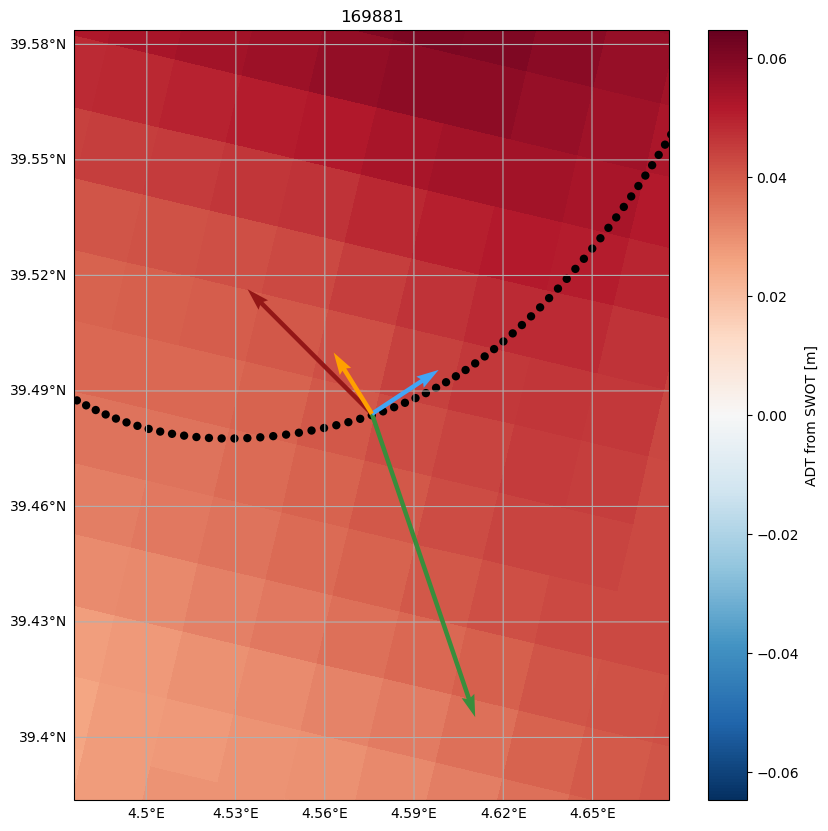

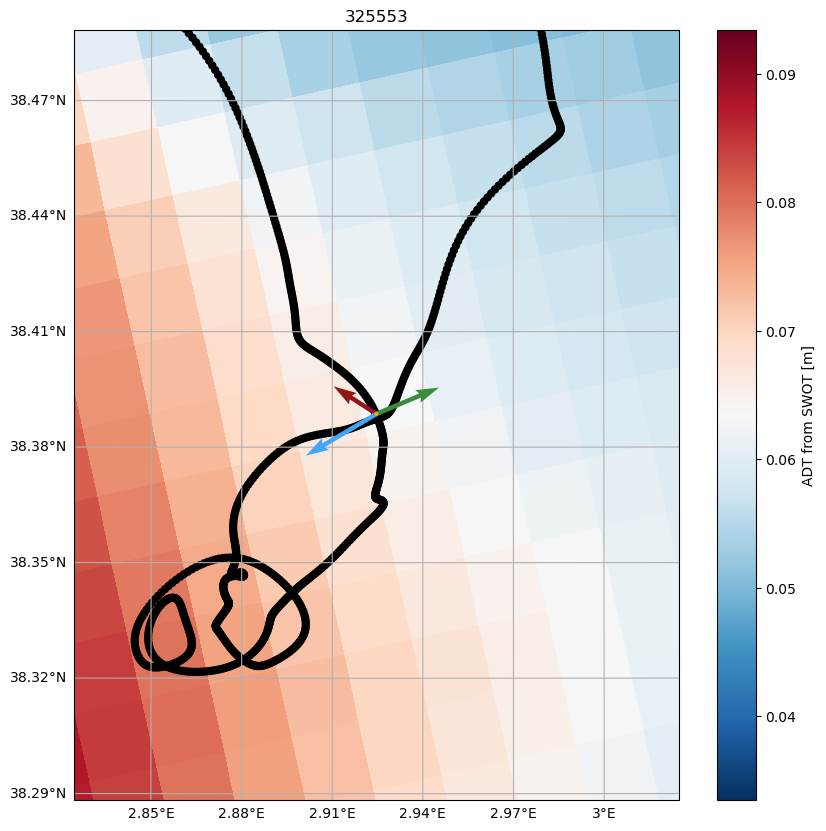

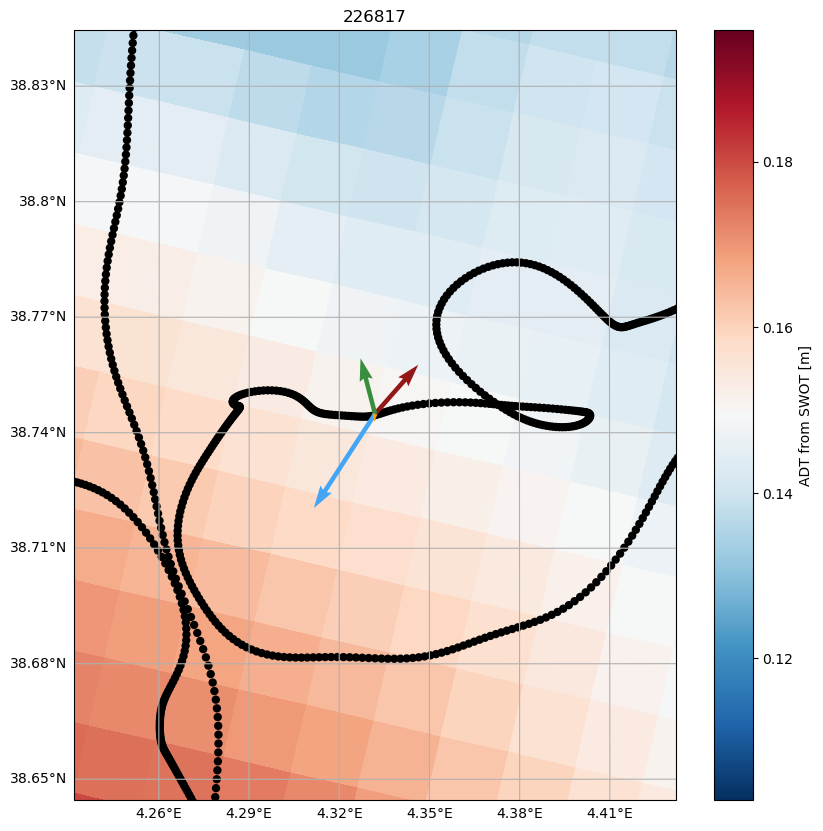

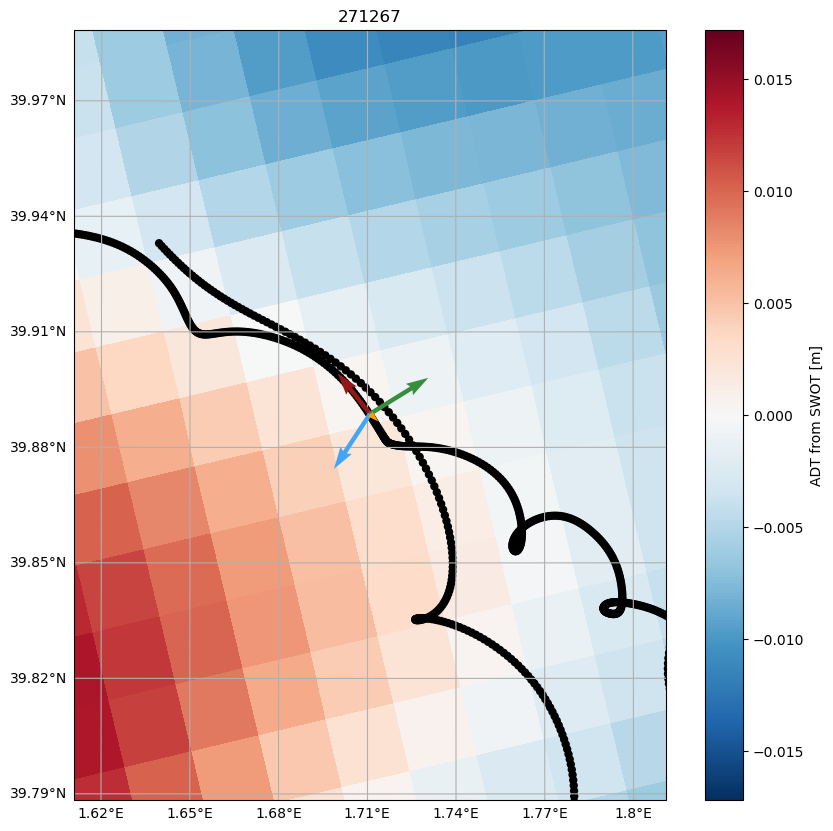

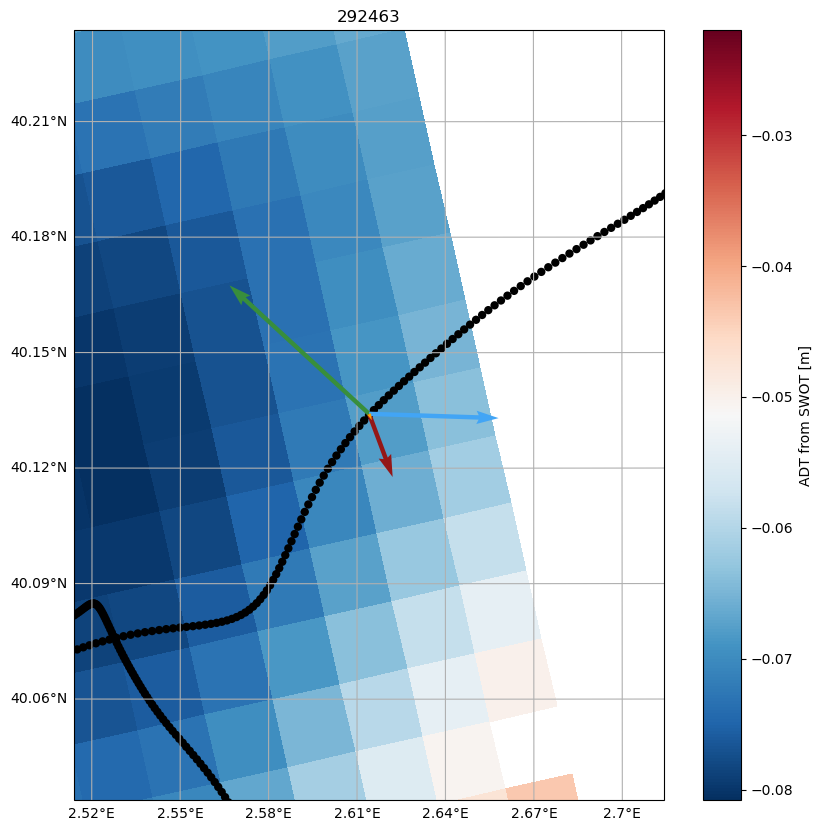

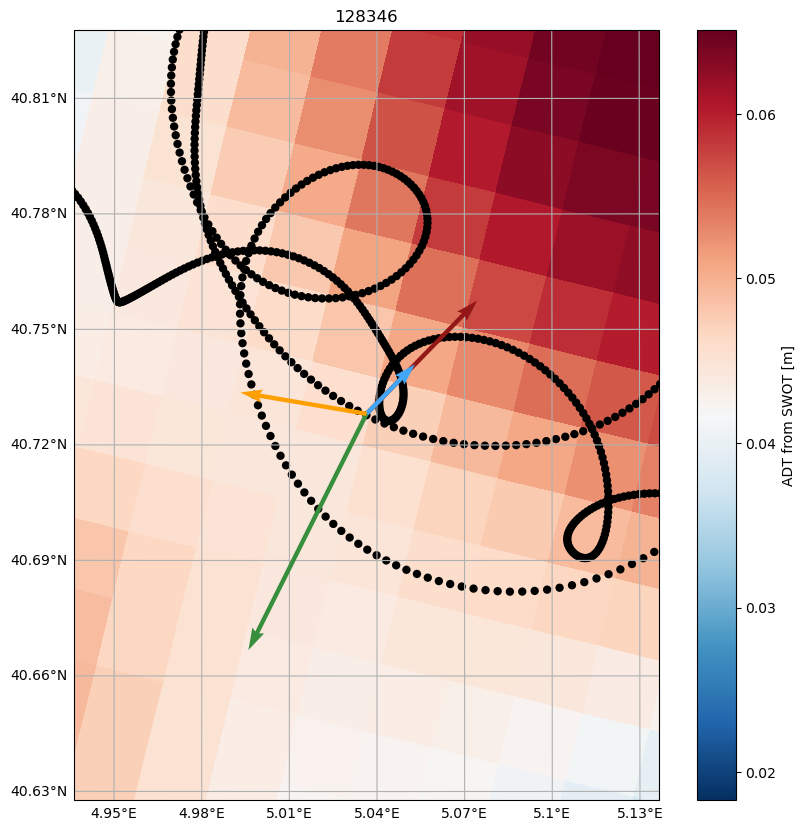

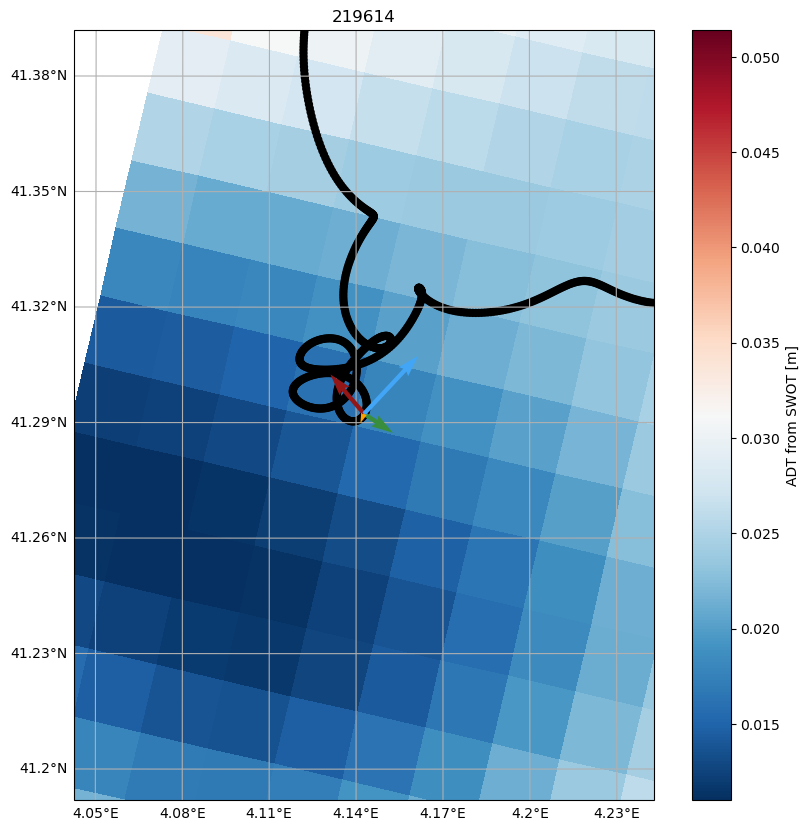

In [22]:
np.random.seed(10)
for rn in np.random.randint(0, ds.dims['row_number'], 15):
    rn = ds.isel(row_number=rn).row_number
    plot_one_coloc(rn)